In [1]:

import os

os.environ["CUDA_VISIBLE_DEVICES"] = "3" #due to the impossibility of changing args.device in SFTTrainer :(

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

from  lora_transfer_pruning.core.pruning_instrumentor import PruningInstrumentor
from transformers import AutoModelForCausalLM
import torch
import compare_utils
from compare_utils import debug_group_prune_step_by_step
from lora_transfer_pruning.adapter.torch_pruning_group_builder import TorchPruningGroupBuilder
from compare_utils import full_attention_test_with_prune
from datetime import datetime


from trl import SFTTrainer, SFTConfig
from transformers import DataCollatorForLanguageModeling



Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [2]:
MODEL = "meta-llama/Llama-3.1-8B-Instruct" 
DEVICE = "cuda:0"
def load_model(device=DEVICE):
    model = AutoModelForCausalLM.from_pretrained(
        MODEL,
        #quantization_config=quantization_config,
        dtype=torch.bfloat16,
        device_map=device,
        #device_map="balanced",
        #max_memory={0: "16GiB", 3: "36GiB"},
    
        # cache_dir="/glazkov-dev/.cache",
    )
    return model

In [3]:
# model = load_model()
# model

In [4]:
# model.model.layers.__len__() #32
NUM_MODEL_LAYERS = 32

In [5]:
def get_batch_size_mb(batch_encoding: dict):
    """Получить размер BatchEncoding в МБ (суммирует все тензоры)
    Args:
        batch_encoding: состоит из input_ids, attention_mask, labels
    """
    total_bytes = sum(
        v.numel() * v.element_size() 
        for v in batch_encoding.values() 
        if torch.is_tensor(v)
    )
    return total_bytes / (1024 ** 2)

def get_model_size_mb(model):
    """Подсчитать примерный размер весов модели в МБ"""
    total_params = 0
    total_bytes = 0
    
    for param in model.parameters():
        num_params = param.numel()
        param_bytes = num_params * param.element_size()
        total_params += num_params
        total_bytes += param_bytes
    
    size_mb = total_bytes / (1024 ** 2)
    
    return size_mb

In [6]:
# get_model_size_mb(model) #15316 mb

In [7]:
# from transformer_lens.model_bridge.bridge import TransformerBridge


# bridge = TransformerBridge.boot_transformers(
#     MODEL,
#     hf_model=model,
#     dtype=torch.float16,
# )

In [8]:
# bridge.original_model

In [9]:
from datasets import load_dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL)

#its instruct model, but we can measure general capabilities of model and perplexity on wikitext before
#and after pruning and fine-tuning
dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="validation",
)
dataset

Dataset({
    features: ['text'],
    num_rows: 3760
})

In [10]:
for i, text in enumerate(dataset):
    print(f"{i}: {text}")
    if i > 10:
        break

0: {'text': ''}
1: {'text': ' = Homarus gammarus = \n'}
2: {'text': ''}
3: {'text': ' Homarus gammarus , known as the European lobster or common lobster , is a species of clawed lobster from the eastern Atlantic Ocean , Mediterranean Sea and parts of the Black Sea . It is closely related to the American lobster , H. americanus . It may grow to a length of 60 cm ( 24 in ) and a mass of 6 kilograms ( 13 lb ) , and bears a conspicuous pair of claws . In life , the lobsters are blue , only becoming " lobster red " on cooking . Mating occurs in the summer , producing eggs which are carried by the females for up to a year before hatching into planktonic larvae . Homarus gammarus is a highly esteemed food , and is widely caught using lobster pots , mostly around the British Isles . \n'}
4: {'text': ''}
5: {'text': ' = = Description = = \n'}
6: {'text': ''}
7: {'text': ' Homarus gammarus is a large crustacean , with a body length up to 60 centimetres ( 24 in ) and weighing up to 5 – 6 kilogram

In [11]:
text_len = 0
for item in dataset:
    text_len += len(item['text'])
print("average symbol len", text_len / len(dataset))

average symbol len 303.76329787234044


In [12]:
CONTEXT_LENGTH = 128
NUM_EVAL_BLOCKS = 256 #(block=batch)
EVAL_BATCH_SIZE = 1

NUM_STEPS = 500
PRINT_EVERY = 25
BATCH_SIZE = 8

In [13]:
train_dataset, eval_dataset, data_collator = None, None, None

def tokenize_dataset():
    '''Ordinary truncative tokenizer'''
    global train_dataset, eval_dataset, data_collator
    
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    def tokenize_function(dataset_item_batch):
        print("ds item", dataset_item_batch['text'].__len__(), dataset_item_batch)
        non_empty_texts = [text for text in dataset_item_batch["text"] if text.strip()]
        tokenized = tokenizer(
            non_empty_texts,
            truncation=True,
            padding=False,
            max_length=CONTEXT_LENGTH,
        )
        # print(tokenized['input_ids'].__len__())
        return tokenized

    original_columns = dataset.column_names
    tokenized_dataset = dataset.map(
        tokenize_function,
        batched=True,
        batch_size=1024, #for calling tokenize_function for huge batches, not batches for model.forward()!
        remove_columns=original_columns,
        desc=f"Tokenizing (max_length={CONTEXT_LENGTH})",
        # num_proc=8
    )

    train_test_split = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
    train_dataset = train_test_split["train"]
    eval_dataset = train_test_split["test"]
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False, #not BERT, causal LM (Llama) (Masked Language Model)
        return_tensors="pt",
    )

tokenize_dataset()
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(eval_dataset)}")
print("example from dataset", next(iter(dataset)))
print("len", len(next(iter(dataset))))
# print("MODEL DEVICE", model.device)
print("example of input_ids", next(iter(train_dataset))["input_ids"])
print("example of input_ids", train_dataset[1]["input_ids"])
print(len(next(iter(train_dataset))["input_ids"]))
print("Tokenized columns:", train_dataset.column_names)

Training samples: 1968
Validation samples: 493
example from dataset {'text': ''}
len 1
example of input_ids [128000, 1443, 1609, 15924, 84, 706, 21682, 7701, 304, 279, 34114, 1443, 56761, 12778, 29888, 23354, 23925, 369, 279, 4101, 1174, 31978, 25012, 304, 279, 1948, 5899, 323, 19261, 11999, 2035, 304, 832, 7230, 662, 578, 1566, 1778, 7230, 574, 304, 220, 679, 16, 1174, 304, 902, 1443, 1609, 15924, 84, 574, 304, 43641, 2035, 1174, 4920, 62189, 13915, 323, 8469, 315, 50733, 460, 662, 66125, 31770, 3196, 389, 1443, 1609, 15924, 84, 706, 1101, 1027, 6004, 1174, 2737, 1957, 12678, 1174, 1401, 27271, 1174, 323, 29760, 304, 2225, 813, 3744, 358, 323, 3744, 8105, 11341, 662, 452, 15249, 6444, 16626, 1461, 439, 872, 4848, 46487, 7075, 3776, 87202, 8762, 23655, 3752, 662, 34711, 14953, 17, 12432, 57392, 60521, 68279, 4168, 3105, 14183, 311, 1443, 1609, 15924, 84]
example of input_ids [128000, 800, 8458, 220, 843, 374, 264, 87195, 37997, 449, 264, 7362, 2722, 354, 82984, 582, 276, 571, 12, 31, 1

In [14]:
tokenizer([tokenizer.eos_token])

{'input_ids': [[128000, 128009]], 'attention_mask': [[1, 1]]}

In [15]:
tokenizer.decode(128000)

'<|begin_of_text|>'

Tokenizer adds tokens - they help model to predict.

In [16]:
tokenizer.decode(128009)

'<|eot_id|>'

In [17]:
# avg_len = 0
# for i in train_dataset:
#     avg_len += len(i["input_ids"])
# avg_len /= len(train_dataset)
# print(f"Average length of input_ids: {avg_len}")

Average length of input_ids: 65.77559840425532 tokens
For wikitext texts.

In [18]:
per_device_train_batch_size = BATCH_SIZE
gradient_accumulation_steps = 2
num_train_epochs = 2
learning_rate = 2e-1
logging_steps = PRINT_EVERY

def create_trainer_unsloth(model, optimizer):
    args=SFTConfig(
                #max_seq_length=MAX_CONTEXT_LENGTH,
                per_device_train_batch_size=per_device_train_batch_size,
                gradient_accumulation_steps=gradient_accumulation_steps,
                warmup_steps=2,
                num_train_epochs=num_train_epochs,
                #max_steps=30,  # TODO: experiment with different values (try 60–200)
                learning_rate=learning_rate,  # TODO: experiment with different values (try 1e-4 to 5e-4)
                logging_steps=logging_steps,
                
                # do_eval=False,
                # eval_strategy="no",
                do_eval=True,
                eval_strategy="steps",
                eval_steps=logging_steps,
                per_device_eval_batch_size=BATCH_SIZE,
                eval_accumulation_steps=None, #не аккумулируем для экономии на метрике
                prediction_loss_only=True, #predicts only loss for eval
                
                gradient_checkpointing=False,
                bf16=True,
                logging_strategy="steps",
                logging_first_step=True,
                save_strategy="no", #sftconfig cant save model_bridge because of ._original_component aliases inside model
                #output_dir="outputs",
                #optim=optimizer,
                #weight_decay=0.01,
                #lr_scheduler_type="linear",
                #seed=SEED,
                # report_to="mlflow",
            )
    # args.device = DEVICE
    
    trainer = SFTTrainer( #supervised fine-tunning trainer
        model=model,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
        optimizers=optimizer,
        data_collator=data_collator,
        #compute_loss_func = None, #for the correct work of grad_accumulation logic when loss / grad_acum in Trainer
        #dont help compute_loss_func = None
        args = args
        # callbacks=[experiment_utils.UpdateGapMLflowCallback(), 
                # experiment_utils.SystemMetricsCallback()]
    )
    # trainer.add_callback(experiment_utils.PerplexityCallback(trainer.get_eval_dataloader(), max_batches=5, eval_every_n_steps=5))
    # trainer.add_callback(experiment_utils.PreciseMemoryCallback())
    #  trainer.add_callback(experiment_utils.ActivationMemoryCallback())
    #почему то unsloth не хочет ставить оптимизатор из optimizers и ставит стандартный из SFTConfig.optim - adam
    trainer.optimizer = optimizer[0]
    trainer.lr_scheduler = optimizer[1]
    return trainer

In [19]:


# validation_text = "\n\n".join(
#     text for text in validation_dataset["text"] if text.strip()
# )
# validation_tokens = tokenizer(
#     validation_text,
#     add_special_tokens=False,
#     return_tensors="pt",
# ).input_ids[0]

# num_blocks = NUM_EVAL_BLOCKS
# assert num_blocks > 0, "Validation split does not contain enough tokens"
# evaluation_blocks = validation_tokens[: num_blocks * CONTEXT_LENGTH].reshape(
#     num_blocks, CONTEXT_LENGTH
# )
# evaluation_blocks.shape

### Without MOE block, just mlp

### Learning with TP and ours

In [20]:
from prune_and_train_model_for_comparsion import full_load_prune_learn_pipeline
FRACTION_ATTN_LAYERS = [28, 29, 30] #32, 40]
FRACTION_MLP_LAYERS = [28, 29, 30] #30] 
FROZE_N_LAYERS = 28
#ATTN_OUT_FRACTION = 0.1
#MLP_OUT_FRACTION = 0.3 
ATTN_OUT_FRACTION = 0.3#[1, 2, 99, 125] #157, 250] #q proj < 128!!!
MLP_OUT_FRACTION = [3, 5, 1000, 2000, 3001, 4002] #< 4096! #5003, 6004, 7005, 8006, 9007, 10009] #up proj
FRACTION_SEED = 0

In [21]:
optimizer_factory = lambda params: (torch.optim.SGD( #works better than AdamW consuming lots of memory
    params,
    lr=learning_rate, #1e-3 too much
    momentum=0.9,
    weight_decay=0.0,
    dampening=0.0,
    nesterov=True
), None) #second None - lr scheduler

In [22]:
from torch.optim import AdamW


# optimizer_factory = lambda params : (AdamW(params, lr=learning_rate), None)

In [23]:
# trainer = create_trainer_unsloth(model, optimizer_factory(model.parameters()))

In [24]:
# torch.cuda.memory._record_memory_history()

trainer = full_load_prune_learn_pipeline(MODEL,
                               load_model,
                               torch.tensor(next(iter(train_dataset))['input_ids'])[None, ...], #evaluation_blocks[:BATCH_SIZE], #will learn 1 batch every time
                               
    FRACTION_ATTN_LAYERS, FRACTION_MLP_LAYERS, ATTN_OUT_FRACTION, MLP_OUT_FRACTION,
    is_torch_pruning=False,
    rescale=False,
    seed=FRACTION_SEED,
    batch_size=BATCH_SIZE,
    optimizer_factory=optimizer_factory,
    num_steps=NUM_STEPS,
    print_every=PRINT_EVERY,
    froze_n_layers=FROZE_N_LAYERS,
    trainer_factory=create_trainer_unsloth,
    froze_embed=True,
    froze_unembed=False
)

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# torch.cuda.memory._dump_snapshot(f"llama_prune_our_bs{BATCH_SIZE}x{CONTEXT_LENGTH}_train_ds_{timestamp}.pickle")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

fraction prune_task:
  blocks.28.attn.q_proj: GroupPruneTask(cols=None, rows=0.3, kv_lora_idxs_deepseek=None)
  blocks.29.attn.q_proj: GroupPruneTask(cols=None, rows=0.3, kv_lora_idxs_deepseek=None)
  blocks.30.attn.q_proj: GroupPruneTask(cols=None, rows=0.3, kv_lora_idxs_deepseek=None)
  blocks.28.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)
  blocks.29.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)
  blocks.30.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)


/glazkov-dev/LoRa-Transfer-Pruning/.venv/lib/python3.10/site-packages/torch_pruning/dependency/graph.py:390: UserWarning: Unwrapped parameters detected: ['model.layers.0._original_component.input_layernorm._original_component.weight', 'model.layers.24._original_component.input_layernorm._original_component.weight', 'model.layers.24._original_component.post_attention_layernorm._original_component.weight', 'model.layers.9._original_component.input_layernorm._original_component.weight', 'model.layers.4._original_component.input_layernorm._original_component.weight', 'model.layers.4._original_component.post_attention_layernorm._original_component.weight', 'model.layers.27._original_component.input_layernorm._original_component.weight', 'model.layers.27._original_component.post_attention_layernorm._original_component.weight', 'model.layers.0._original_component.post_attention_layernorm._original_component.weight', 'model.layers.13._original_component.input_layernorm._original_component.weig

removed group indices by module:
  blocks.28.attn.q_proj: count=1216, idxs=[0, 1, 3, 5, 6, 7, 8, 9, 14, 18, 19, 21, 27, 28, 34, 44, 47, 49, 59, 64, 65, 67, 69, 70, 71, 72, 73, 78, 82, 83, 85, 91, 92, 98, 108, 111, 113, 123, 128, 129, 131, 133, 134, 135, 136, 137, 142, 146, 147, 149, 155, 156, 162, 172, 175, 177, 187, 192, 193, 195, 197, 198, 199, 200, 201, 206, 210, 211, 213, 219, 220, 226, 236, 239, 241, 251, 256, 257, 259, 261, 262, 263, 264, 265, 270, 274, 275, 277, 283, 284, 290, 300, 303, 305, 315, 320, 321, 323, 325, 326, 327, 328, 329, 334, 338, 339, 341, 347, 348, 354, 364, 367, 369, 379, 384, 385, 387, 389, 390, 391, 392, 393, 398, 402, 403, 405, 411, 412, 418, 428, 431, 433, 443, 448, 449, 451, 453, 454, 455, 456, 457, 462, 466, 467, 469, 475, 476, 482, 492, 495, 497, 507, 512, 513, 515, 517, 518, 519, 520, 521, 526, 530, 531, 533, 539, 540, 546, 556, 559, 561, 571, 576, 577, 579, 581, 582, 583, 584, 585, 590, 594, 595, 597, 603, 604, 610, 620, 623, 625, 635, 640, 641, 643, 6

In [47]:
torch.cuda.empty_cache()

What if set initial lr very big? Because we want to re-train model and find another optima?

In [28]:
trainer.state.log_history[-1]

{'train_runtime': 110.3472,
 'train_samples_per_second': 17.835,
 'train_steps_per_second': 2.972,
 'total_flos': 1.5621377406879744e+16,
 'train_loss': 2.886306684191634,
 'entropy': 2.8626243670781455,
 'num_tokens': 196515.0,
 'mean_token_accuracy': 0.45165616273880005,
 'epoch': 1.0,
 'step': 328}

In [ ]:
our_history

In [ ]:
torch.cuda.max_memory_allocated(DEVICE) / 1024 / 1024

33390.9775390625

In [ ]:
torch.cuda.max_memory_reserved(DEVICE) / 1024 / 1024

39246.0

In [ ]:
torch.cuda.memory_reserved(DEVICE) / 1024 / 1024

39086.0

In [ ]:
torch.cuda.memory_allocated(DEVICE) / 1024 / 1024

17.25

In [24]:
# torch.cuda.memory._record_memory_history()


trainer_tp = full_load_prune_learn_pipeline(MODEL,
                               load_model,
                               torch.tensor(next(iter(train_dataset))['input_ids'])[None, ...], #evaluation_blocks[:BATCH_SIZE], #will learn 1 batch every time
                               
    FRACTION_ATTN_LAYERS, FRACTION_MLP_LAYERS, ATTN_OUT_FRACTION, MLP_OUT_FRACTION,
    is_torch_pruning=True,
    rescale=False,
    seed=FRACTION_SEED,
    batch_size=BATCH_SIZE,
    optimizer_factory=optimizer_factory,
    num_steps=NUM_STEPS,
    print_every=PRINT_EVERY,
    froze_n_layers=FROZE_N_LAYERS,
    trainer_factory=create_trainer_unsloth,
    froze_embed=True,
    froze_unembed=False
)


# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# torch.cuda.memory._dump_snapshot(f"llama_prune_tp_bs2x256_{timestamp}.pickle")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

fraction prune_task:
  blocks.28.attn.q_proj: GroupPruneTask(cols=None, rows=0.3, kv_lora_idxs_deepseek=None)
  blocks.29.attn.q_proj: GroupPruneTask(cols=None, rows=0.3, kv_lora_idxs_deepseek=None)
  blocks.30.attn.q_proj: GroupPruneTask(cols=None, rows=0.3, kv_lora_idxs_deepseek=None)
  blocks.28.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)
  blocks.29.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)
  blocks.30.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)


/glazkov-dev/LoRa-Transfer-Pruning/.venv/lib/python3.10/site-packages/torch_pruning/dependency/graph.py:390: UserWarning: Unwrapped parameters detected: ['model.layers.6._original_component.input_layernorm._original_component.weight', 'model.layers.28._original_component.post_attention_layernorm._original_component.weight', 'model.layers.30._original_component.input_layernorm._original_component.weight', 'model.layers.9._original_component.post_attention_layernorm._original_component.weight', 'model.layers.16._original_component.post_attention_layernorm._original_component.weight', 'model.layers.2._original_component.post_attention_layernorm._original_component.weight', 'model.layers.14._original_component.input_layernorm._original_component.weight', 'model.layers.14._original_component.post_attention_layernorm._original_component.weight', 'model.layers.16._original_component.input_layernorm._original_component.weight', 'model.layers.19._original_component.post_attention_layernorm._ori

removed group indices by module:
  blocks.28.attn.q_proj: count=1216, idxs=[0, 1, 3, 5, 6, 7, 8, 9, 14, 18, 19, 21, 27, 28, 34, 44, 47, 49, 59, 64, 65, 67, 69, 70, 71, 72, 73, 78, 82, 83, 85, 91, 92, 98, 108, 111, 113, 123, 128, 129, 131, 133, 134, 135, 136, 137, 142, 146, 147, 149, 155, 156, 162, 172, 175, 177, 187, 192, 193, 195, 197, 198, 199, 200, 201, 206, 210, 211, 213, 219, 220, 226, 236, 239, 241, 251, 256, 257, 259, 261, 262, 263, 264, 265, 270, 274, 275, 277, 283, 284, 290, 300, 303, 305, 315, 320, 321, 323, 325, 326, 327, 328, 329, 334, 338, 339, 341, 347, 348, 354, 364, 367, 369, 379, 384, 385, 387, 389, 390, 391, 392, 393, 398, 402, 403, 405, 411, 412, 418, 428, 431, 433, 443, 448, 449, 451, 453, 454, 455, 456, 457, 462, 466, 467, 469, 475, 476, 482, 492, 495, 497, 507, 512, 513, 515, 517, 518, 519, 520, 521, 526, 530, 531, 533, 539, 540, 546, 556, 559, 561, 571, 576, 577, 579, 581, 582, 583, 584, 585, 590, 594, 595, 597, 603, 604, 610, 620, 623, 625, 635, 640, 641, 643, 6

In [25]:
def plot_training_history(history, *, title="Training dynamics"):
    """Plot interleaved Trainer train/eval logs in one figure."""
    import math
    import numbers
    import matplotlib.pyplot as plt

    if not history:
        raise ValueError("history is empty")

    aliases = {"gradient_norm": "grad_norm"}
    excluded = {
        "step", "epoch", "train_loss", "train_runtime",
        "train_samples_per_second", "train_steps_per_second",
        "eval_runtime", "eval_samples_per_second",
        "eval_steps_per_second", "total_flos",
    }

    series = {}
    for row in history:
        if not isinstance(row.get("step"), numbers.Number):
            continue
        step = row["step"]
        for raw_key, value in row.items():
            if raw_key in excluded or not isinstance(value, numbers.Number):
                continue
            split = "eval" if raw_key.startswith("eval_") else "train"
            metric = raw_key.removeprefix("eval_")
            metric = aliases.get(metric, metric)
            series.setdefault(metric, {}).setdefault(split, []).append(
                (step, float(value))
            )

    # Trainer normally logs loss but not perplexity. Derive it separately
    # for train and eval, so exp(mean loss) is shown at the same steps.
    if "loss" in series and "perplexity" not in series:
        series["perplexity"] = {
            split: [
                (step, math.exp(value) if value < 80 else math.inf)
                for step, value in points
            ]
            for split, points in series["loss"].items()
        }

    preferred_order = [
        "loss", "perplexity", "grad_norm", "learning_rate",
        "mean_token_accuracy", "entropy", "num_tokens",
    ]
    metric_names = [name for name in preferred_order if name in series]
    metric_names += [name for name in series if name not in metric_names]
    if not metric_names:
        raise ValueError("history contains no step-wise numeric metrics")

    labels = {
        "loss": "Loss",
        "perplexity": "Perplexity",
        "grad_norm": "Gradient norm",
        "learning_rate": "Learning rate",
        "mean_token_accuracy": "Mean token accuracy",
        "entropy": "Entropy",
        "num_tokens": "Processed tokens",
    }
    ncols = min(2, len(metric_names))
    nrows = math.ceil(len(metric_names) / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(7 * ncols, 4 * nrows),
        squeeze=False,
        sharex=True,
    )
    flat_axes = list(axes.flat)

    styles = {
        "train": dict(marker="o", linewidth=1.8, alpha=0.8),
        "eval": dict(marker="s", linewidth=2.4, linestyle="--"),
    }
    for ax, metric_name in zip(flat_axes, metric_names):
        label = labels.get(
            metric_name,
            metric_name.replace("_", " ").title(),
        )
        for split in ("train", "eval"):
            points = series[metric_name].get(split, [])
            if not points:
                continue
            steps, values = zip(*points)
            ax.plot(
                steps,
                values,
                label=split.capitalize(),
                **styles[split],
            )

        ax.set(
            title=label,
            xlabel="Optimizer step",
            ylabel=label,
        )
        ax.grid(True, alpha=0.3)
        ax.legend()

        if metric_name == "learning_rate":
            ax.ticklabel_format(
                axis="y",
                style="sci",
                scilimits=(0, 0),
            )

    for ax in flat_axes[len(metric_names):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    return fig, axes


In [44]:
trainer.state.log_history[16]

{'eval_loss': 2.5420289039611816,
 'eval_model_preparation_time': 0.032,
 'eval_runtime': 18.2229,
 'eval_samples_per_second': 27.054,
 'eval_steps_per_second': 3.402,
 'eval_entropy': 1.8761375142681984,
 'eval_num_tokens': 237608.0,
 'eval_mean_token_accuracy': 0.4891804317312856,
 'epoch': 1.6260162601626016,
 'step': 200}

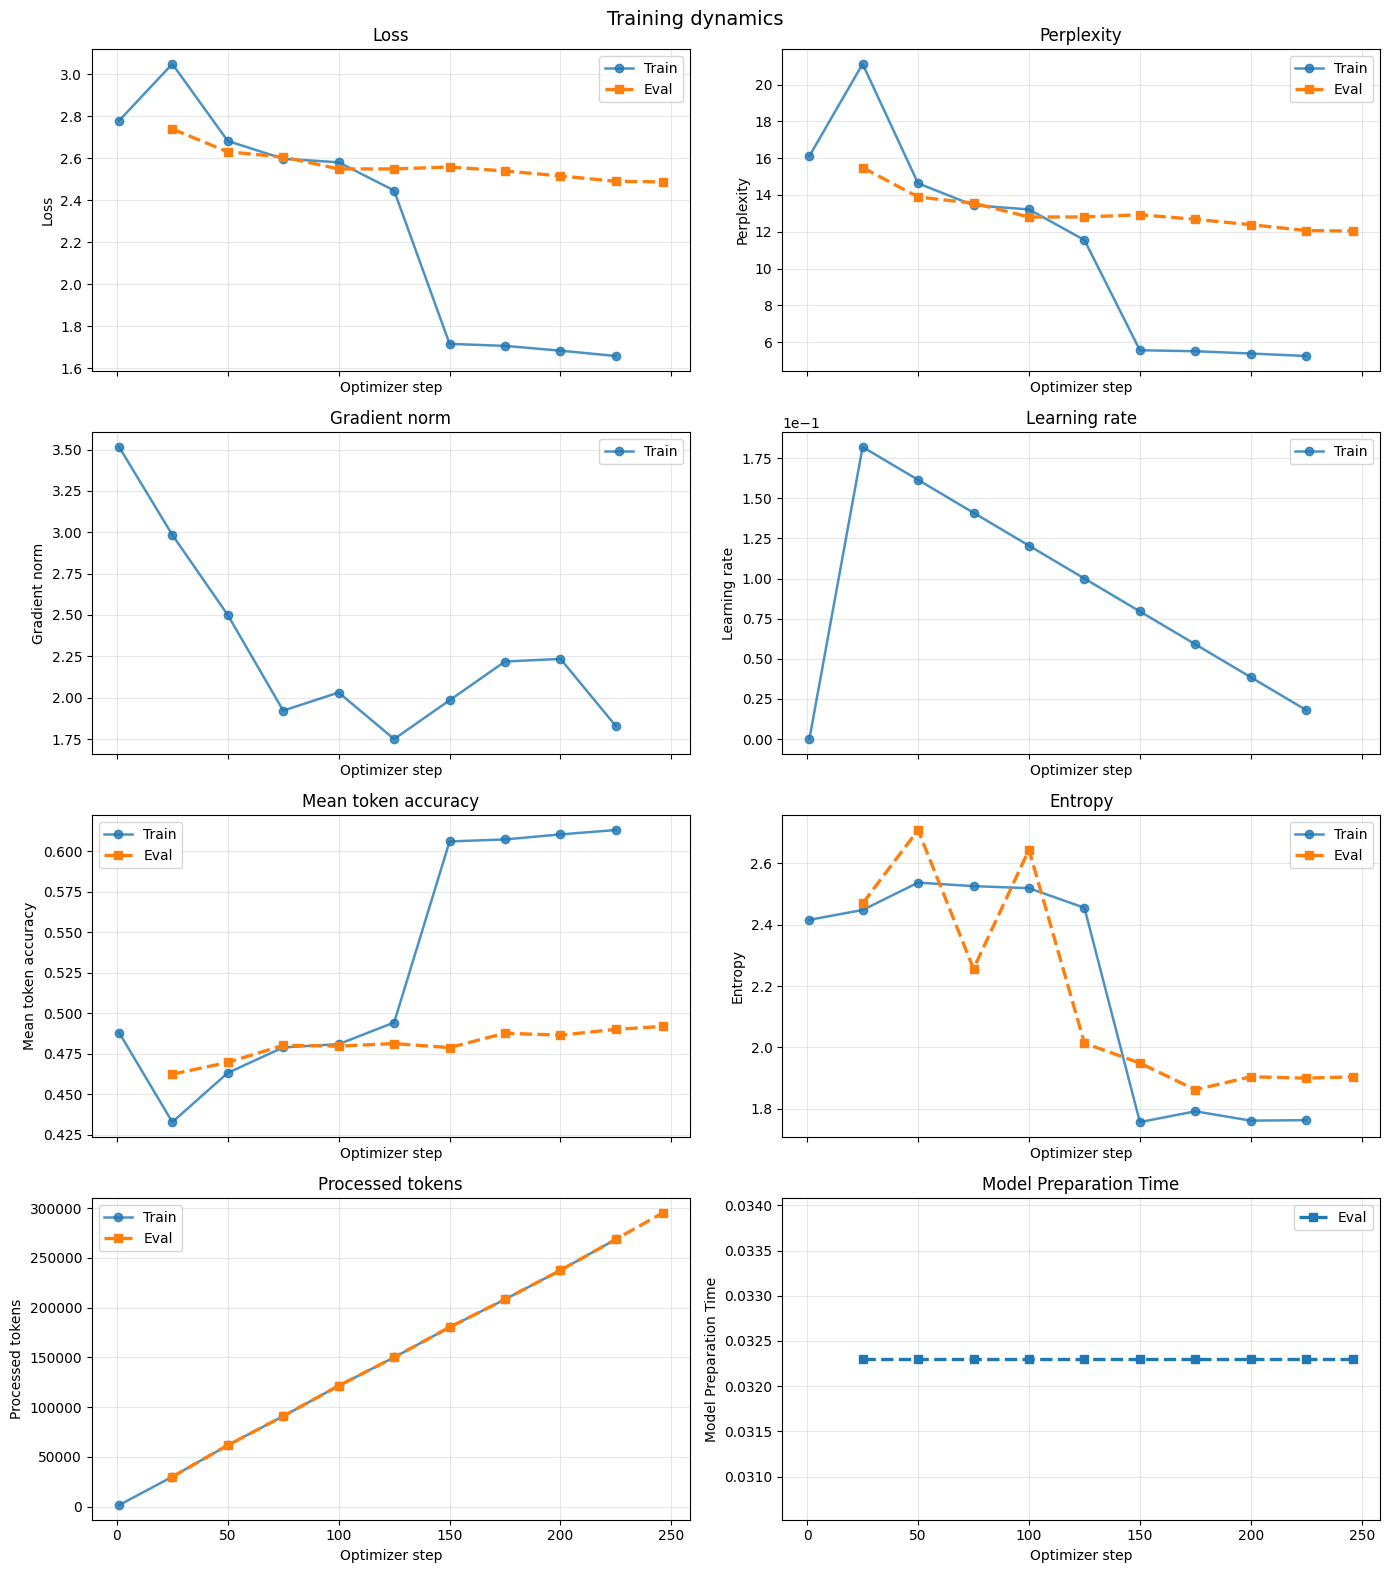

In [26]:
_ = plot_training_history(trainer_tp.state.log_history)

Compare our and tp last metrics

In [ ]:
#our {'train_runtime': '290.9', 'train_samples_per_second': '13.53', 'train_steps_per_second': '0.846', 'train_loss': '2.282', 'epoch': '2'}
#{'eval_loss': '2.509', 'eval_model_preparation_time': '0.032', 'eval_runtime': '18.09', 'eval_samples_per_second': '27.26', 'eval_steps_per_second': '3.428', 'eval_entropy': '1.861', 'eval_num_tokens': '2.951e+05', 'eval_mean_token_accuracy': '0.4942', 'epoch': '2'}

#tp {'train_runtime': '290.1', 'train_samples_per_second': '13.57', 'train_steps_per_second': '0.848', 'train_loss': '2.189', 'epoch': '2'}
#{'eval_loss': '2.488', 'eval_model_preparation_time': '0.0323', 'eval_runtime': '18.26', 'eval_samples_per_second': '27.01', 'eval_steps_per_second': '3.396', 'eval_entropy': '1.904', 'eval_num_tokens': '2.951e+05', 'eval_mean_token_accuracy': '0.4918', 'epoch': '2'}

Check equivalence of pruned q_proj indices 

In [ ]:
[0, 1, 3, 5, 6, 7, 8, 9, 14, 18, 19, 21, 27, 28, 34, 44, 47, 49, 59, 64, 65, 67, 69, 70, 71, 72, 73, 78, 82, 83, 85, 91, 92, 98, 108, 111, 113, 123, 128, 129, 131, 133, 134, 135, 136, 137, 142, 146, 147, 149, 155, 156, 162, 172, 175, 177, 187, 192, 193, 195, 197, 198, 199, 200, 201, 206, 210, 211, 213, 219, 220, 226, 236, 239, 241, 251, 256, 257, 259, 261, 262, 263, 264, 265, 270, 274, 275, 277, 283, 284, 290, 300, 303, 305, 315, 320, 321, 323, 325, 326, 327, 328, 329, 334, 338, 339, 341, 347, 348, 354, 364, 367, 369, 379, 384, 385, 387, 389, 390, 391, 392, 393, 398, 402, 403, 405, 411, 412, 418, 428, 431, 433, 443, 448, 449, 451, 453, 454, 455, 456, 457, 462, 466, 467, 469, 475, 476, 482, 492, 495, 497, 507, 512, 513, 515, 517, 518, 519, 520, 521, 526, 530, 531, 533, 539, 540, 546, 556, 559, 561, 571, 576, 577, 579, 581, 582, 583, 584, 585, 590, 594, 595, 597, 603, 604, 610, 620, 623, 625, 635, 640, 641, 643, 645, 646, 647, 648, 649, 654, 658, 659, 661, 667, 668, 674, 684, 687, 689, 699, 704, 705, 707, 709, 710, 711, 712, 713, 718, 722, 723, 725, 731, 732, 738, 748, 751, 753, 763, 768, 769, 771, 773, 774, 775, 776, 777, 782, 786, 787, 789, 795, 796, 802, 812, 815, 817, 827, 832, 833, 835, 837, 838, 839, 840, 841, 846, 850, 851, 853, 859, 860, 866, 876, 879, 881, 891, 896, 897, 899, 901, 902, 903, 904, 905, 910, 914, 915, 917, 923, 924, 930, 940, 943, 945, 955, 960, 961, 963, 965, 966, 967, 968, 969, 974, 978, 979, 981, 987, 988, 994, 1004, 1007, 1009, 1019, 1024, 1025, 1027, 1029, 1030, 1031, 1032, 1033, 1038, 1042, 1043, 1045, 1051, 1052, 1058, 1068, 1071, 1073, 1083, 1088, 1089, 1091, 1093, 1094, 1095, 1096, 1097, 1102, 1106, 1107, 1109, 1115, 1116, 1122, 1132, 1135, 1137, 1147, 1152, 1153, 1155, 1157, 1158, 1159, 1160, 1161, 1166, 1170, 1171, 1173, 1179, 1180, 1186, 1196, 1199, 1201, 1211, 1216, 1217, 1219, 1221, 1222, 1223, 1224, 1225, 1230, 1234, 1235, 1237, 1243, 1244, 1250, 1260, 1263, 1265, 1275, 1280, 1281, 1283, 1285, 1286, 1287, 1288, 1289, 1294, 1298, 1299, 1301, 1307, 1308, 1314, 1324, 1327, 1329, 1339, 1344, 1345, 1347, 1349, 1350, 1351, 1352, 1353, 1358, 1362, 1363, 1365, 1371, 1372, 1378, 1388, 1391, 1393, 1403, 1408, 1409, 1411, 1413, 1414, 1415, 1416, 1417, 1422, 1426, 1427, 1429, 1435, 1436, 1442, 1452, 1455, 1457, 1467, 1472, 1473, 1475, 1477, 1478, 1479, 1480, 1481, 1486, 1490, 1491, 1493, 1499, 1500, 1506, 1516, 1519, 1521, 1531, 1536, 1537, 1539, 1541, 1542, 1543, 1544, 1545, 1550, 1554, 1555, 1557, 1563, 1564, 1570, 1580, 1583, 1585, 1595, 1600, 1601, 1603, 1605, 1606, 1607, 1608, 1609, 1614, 1618, 1619, 1621, 1627, 1628, 1634, 1644, 1647, 1649, 1659, 1664, 1665, 1667, 1669, 1670, 1671, 1672, 1673, 1678, 1682, 1683, 1685, 1691, 1692, 1698, 1708, 1711, 1713, 1723, 1728, 1729, 1731, 1733, 1734, 1735, 1736, 1737, 1742, 1746, 1747, 1749, 1755, 1756, 1762, 1772, 1775, 1777, 1787, 1792, 1793, 1795, 1797, 1798, 1799, 1800, 1801, 1806, 1810, 1811, 1813, 1819, 1820, 1826, 1836, 1839, 1841, 1851, 1856, 1857, 1859, 1861, 1862, 1863, 1864, 1865, 1870, 1874, 1875, 1877, 1883, 1884, 1890, 1900, 1903, 1905, 1915, 1920, 1921, 1923, 1925, 1926, 1927, 1928, 1929, 1934, 1938, 1939, 1941, 1947, 1948, 1954, 1964, 1967, 1969, 1979, 1984, 1985, 1987, 1989, 1990, 1991, 1992, 1993, 1998, 2002, 2003, 2005, 2011, 2012, 2018, 2028, 2031, 2033, 2043, 2048, 2049, 2051, 2053, 2054, 2055, 2056, 2057, 2062, 2066, 2067, 2069, 2075, 2076, 2082, 2092, 2095, 2097, 2107, 2112, 2113, 2115, 2117, 2118, 2119, 2120, 2121, 2126, 2130, 2131, 2133, 2139, 2140, 2146, 2156, 2159, 2161, 2171, 2176, 2177, 2179, 2181, 2182, 2183, 2184, 2185, 2190, 2194, 2195, 2197, 2203, 2204, 2210, 2220, 2223, 2225, 2235, 2240, 2241, 2243, 2245, 2246, 2247, 2248, 2249, 2254, 2258, 2259, 2261, 2267, 2268, 2274, 2284, 2287, 2289, 2299, 2304, 2305, 2307, 2309, 2310, 2311, 2312, 2313, 2318, 2322, 2323, 2325, 2331, 2332, 2338, 2348, 2351, 2353, 2363, 2368, 2369, 2371, 2373, 2374, 2375, 2376, 2377, 2382, 2386, 2387, 2389, 2395, 2396, 2402, 2412, 2415, 2417, 2427, 2432, 2433, 2435, 2437, 2438, 2439, 2440, 2441, 2446, 2450, 2451, 2453, 2459, 2460, 2466, 2476, 2479, 2481, 2491, 2496, 2497, 2499, 2501, 2502, 2503, 2504, 2505, 2510, 2514, 2515, 2517, 2523, 2524, 2530, 2540, 2543, 2545, 2555, 2560, 2561, 2563, 2565, 2566, 2567, 2568, 2569, 2574, 2578, 2579, 2581, 2587, 2588, 2594, 2604, 2607, 2609, 2619, 2624, 2625, 2627, 2629, 2630, 2631, 2632, 2633, 2638, 2642, 2643, 2645, 2651, 2652, 2658, 2668, 2671, 2673, 2683, 2688, 2689, 2691, 2693, 2694, 2695, 2696, 2697, 2702, 2706, 2707, 2709, 2715, 2716, 2722, 2732, 2735, 2737, 2747, 2752, 2753, 2755, 2757, 2758, 2759, 2760, 2761, 2766, 2770, 2771, 2773, 2779, 2780, 2786, 2796, 2799, 2801, 2811, 2816, 2817, 2819, 2821, 2822, 2823, 2824, 2825, 2830, 2834, 2835, 2837, 2843, 2844, 2850, 2860, 2863, 2865, 2875, 2880, 2881, 2883, 2885, 2886, 2887, 2888, 2889, 2894, 2898, 2899, 2901, 2907, 2908, 2914, 2924, 2927, 2929, 2939, 2944, 2945, 2947, 2949, 2950, 2951, 2952, 2953, 2958, 2962, 2963, 2965, 2971, 2972, 2978, 2988, 2991, 2993, 3003, 3008, 3009, 3011, 3013, 3014, 3015, 3016, 3017, 3022, 3026, 3027, 3029, 3035, 3036, 3042, 3052, 3055, 3057, 3067, 3072, 3073, 3075, 3077, 3078, 3079, 3080, 3081, 3086, 3090, 3091, 3093, 3099, 3100, 3106, 3116, 3119, 3121, 3131, 3136, 3137, 3139, 3141, 3142, 3143, 3144, 3145, 3150, 3154, 3155, 3157, 3163, 3164, 3170, 3180, 3183, 3185, 3195, 3200, 3201, 3203, 3205, 3206, 3207, 3208, 3209, 3214, 3218, 3219, 3221, 3227, 3228, 3234, 3244, 3247, 3249, 3259, 3264, 3265, 3267, 3269, 3270, 3271, 3272, 3273, 3278, 3282, 3283, 3285, 3291, 3292, 3298, 3308, 3311, 3313, 3323, 3328, 3329, 3331, 3333, 3334, 3335, 3336, 3337, 3342, 3346, 3347, 3349, 3355, 3356, 3362, 3372, 3375, 3377, 3387, 3392, 3393, 3395, 3397, 3398, 3399, 3400, 3401, 3406, 3410, 3411, 3413, 3419, 3420, 3426, 3436, 3439, 3441, 3451, 3456, 3457, 3459, 3461, 3462, 3463, 3464, 3465, 3470, 3474, 3475, 3477, 3483, 3484, 3490, 3500, 3503, 3505, 3515, 3520, 3521, 3523, 3525, 3526, 3527, 3528, 3529, 3534, 3538, 3539, 3541, 3547, 3548, 3554, 3564, 3567, 3569, 3579, 3584, 3585, 3587, 3589, 3590, 3591, 3592, 3593, 3598, 3602, 3603, 3605, 3611, 3612, 3618, 3628, 3631, 3633, 3643, 3648, 3649, 3651, 3653, 3654, 3655, 3656, 3657, 3662, 3666, 3667, 3669, 3675, 3676, 3682, 3692, 3695, 3697, 3707, 3712, 3713, 3715, 3717, 3718, 3719, 3720, 3721, 3726, 3730, 3731, 3733, 3739, 3740, 3746, 3756, 3759, 3761, 3771, 3776, 3777, 3779, 3781, 3782, 3783, 3784, 3785, 3790, 3794, 3795, 3797, 3803, 3804, 3810, 3820, 3823, 3825, 3835, 3840, 3841, 3843, 3845, 3846, 3847, 3848, 3849, 3854, 3858, 3859, 3861, 3867, 3868, 3874, 3884, 3887, 3889, 3899, 3904, 3905, 3907, 3909, 3910, 3911, 3912, 3913, 3918, 3922, 3923, 3925, 3931, 3932, 3938, 3948, 3951, 3953, 3963, 3968, 3969, 3971, 3973, 3974, 3975, 3976, 3977, 3982, 3986, 3987, 3989, 3995, 3996, 4002, 4012, 4015, 4017, 4027, 4032, 4033, 4035, 4037, 4038, 4039, 4040, 4041, 4046, 4050, 4051, 4053, 4059, 4060, 4066, 4076, 4079, 4081, 4091] \
    ==  [0, 1, 3, 5, 6, 7, 8, 9, 14, 18, 19, 21, 27, 28, 34, 44, 47, 49, 59, 64, 65, 67, 69, 70, 71, 72, 73, 78, 82, 83, 85, 91, 92, 98, 108, 111, 113, 123, 128, 129, 131, 133, 134, 135, 136, 137, 142, 146, 147, 149, 155, 156, 162, 172, 175, 177, 187, 192, 193, 195, 197, 198, 199, 200, 201, 206, 210, 211, 213, 219, 220, 226, 236, 239, 241, 251, 256, 257, 259, 261, 262, 263, 264, 265, 270, 274, 275, 277, 283, 284, 290, 300, 303, 305, 315, 320, 321, 323, 325, 326, 327, 328, 329, 334, 338, 339, 341, 347, 348, 354, 364, 367, 369, 379, 384, 385, 387, 389, 390, 391, 392, 393, 398, 402, 403, 405, 411, 412, 418, 428, 431, 433, 443, 448, 449, 451, 453, 454, 455, 456, 457, 462, 466, 467, 469, 475, 476, 482, 492, 495, 497, 507, 512, 513, 515, 517, 518, 519, 520, 521, 526, 530, 531, 533, 539, 540, 546, 556, 559, 561, 571, 576, 577, 579, 581, 582, 583, 584, 585, 590, 594, 595, 597, 603, 604, 610, 620, 623, 625, 635, 640, 641, 643, 645, 646, 647, 648, 649, 654, 658, 659, 661, 667, 668, 674, 684, 687, 689, 699, 704, 705, 707, 709, 710, 711, 712, 713, 718, 722, 723, 725, 731, 732, 738, 748, 751, 753, 763, 768, 769, 771, 773, 774, 775, 776, 777, 782, 786, 787, 789, 795, 796, 802, 812, 815, 817, 827, 832, 833, 835, 837, 838, 839, 840, 841, 846, 850, 851, 853, 859, 860, 866, 876, 879, 881, 891, 896, 897, 899, 901, 902, 903, 904, 905, 910, 914, 915, 917, 923, 924, 930, 940, 943, 945, 955, 960, 961, 963, 965, 966, 967, 968, 969, 974, 978, 979, 981, 987, 988, 994, 1004, 1007, 1009, 1019, 1024, 1025, 1027, 1029, 1030, 1031, 1032, 1033, 1038, 1042, 1043, 1045, 1051, 1052, 1058, 1068, 1071, 1073, 1083, 1088, 1089, 1091, 1093, 1094, 1095, 1096, 1097, 1102, 1106, 1107, 1109, 1115, 1116, 1122, 1132, 1135, 1137, 1147, 1152, 1153, 1155, 1157, 1158, 1159, 1160, 1161, 1166, 1170, 1171, 1173, 1179, 1180, 1186, 1196, 1199, 1201, 1211, 1216, 1217, 1219, 1221, 1222, 1223, 1224, 1225, 1230, 1234, 1235, 1237, 1243, 1244, 1250, 1260, 1263, 1265, 1275, 1280, 1281, 1283, 1285, 1286, 1287, 1288, 1289, 1294, 1298, 1299, 1301, 1307, 1308, 1314, 1324, 1327, 1329, 1339, 1344, 1345, 1347, 1349, 1350, 1351, 1352, 1353, 1358, 1362, 1363, 1365, 1371, 1372, 1378, 1388, 1391, 1393, 1403, 1408, 1409, 1411, 1413, 1414, 1415, 1416, 1417, 1422, 1426, 1427, 1429, 1435, 1436, 1442, 1452, 1455, 1457, 1467, 1472, 1473, 1475, 1477, 1478, 1479, 1480, 1481, 1486, 1490, 1491, 1493, 1499, 1500, 1506, 1516, 1519, 1521, 1531, 1536, 1537, 1539, 1541, 1542, 1543, 1544, 1545, 1550, 1554, 1555, 1557, 1563, 1564, 1570, 1580, 1583, 1585, 1595, 1600, 1601, 1603, 1605, 1606, 1607, 1608, 1609, 1614, 1618, 1619, 1621, 1627, 1628, 1634, 1644, 1647, 1649, 1659, 1664, 1665, 1667, 1669, 1670, 1671, 1672, 1673, 1678, 1682, 1683, 1685, 1691, 1692, 1698, 1708, 1711, 1713, 1723, 1728, 1729, 1731, 1733, 1734, 1735, 1736, 1737, 1742, 1746, 1747, 1749, 1755, 1756, 1762, 1772, 1775, 1777, 1787, 1792, 1793, 1795, 1797, 1798, 1799, 1800, 1801, 1806, 1810, 1811, 1813, 1819, 1820, 1826, 1836, 1839, 1841, 1851, 1856, 1857, 1859, 1861, 1862, 1863, 1864, 1865, 1870, 1874, 1875, 1877, 1883, 1884, 1890, 1900, 1903, 1905, 1915, 1920, 1921, 1923, 1925, 1926, 1927, 1928, 1929, 1934, 1938, 1939, 1941, 1947, 1948, 1954, 1964, 1967, 1969, 1979, 1984, 1985, 1987, 1989, 1990, 1991, 1992, 1993, 1998, 2002, 2003, 2005, 2011, 2012, 2018, 2028, 2031, 2033, 2043, 2048, 2049, 2051, 2053, 2054, 2055, 2056, 2057, 2062, 2066, 2067, 2069, 2075, 2076, 2082, 2092, 2095, 2097, 2107, 2112, 2113, 2115, 2117, 2118, 2119, 2120, 2121, 2126, 2130, 2131, 2133, 2139, 2140, 2146, 2156, 2159, 2161, 2171, 2176, 2177, 2179, 2181, 2182, 2183, 2184, 2185, 2190, 2194, 2195, 2197, 2203, 2204, 2210, 2220, 2223, 2225, 2235, 2240, 2241, 2243, 2245, 2246, 2247, 2248, 2249, 2254, 2258, 2259, 2261, 2267, 2268, 2274, 2284, 2287, 2289, 2299, 2304, 2305, 2307, 2309, 2310, 2311, 2312, 2313, 2318, 2322, 2323, 2325, 2331, 2332, 2338, 2348, 2351, 2353, 2363, 2368, 2369, 2371, 2373, 2374, 2375, 2376, 2377, 2382, 2386, 2387, 2389, 2395, 2396, 2402, 2412, 2415, 2417, 2427, 2432, 2433, 2435, 2437, 2438, 2439, 2440, 2441, 2446, 2450, 2451, 2453, 2459, 2460, 2466, 2476, 2479, 2481, 2491, 2496, 2497, 2499, 2501, 2502, 2503, 2504, 2505, 2510, 2514, 2515, 2517, 2523, 2524, 2530, 2540, 2543, 2545, 2555, 2560, 2561, 2563, 2565, 2566, 2567, 2568, 2569, 2574, 2578, 2579, 2581, 2587, 2588, 2594, 2604, 2607, 2609, 2619, 2624, 2625, 2627, 2629, 2630, 2631, 2632, 2633, 2638, 2642, 2643, 2645, 2651, 2652, 2658, 2668, 2671, 2673, 2683, 2688, 2689, 2691, 2693, 2694, 2695, 2696, 2697, 2702, 2706, 2707, 2709, 2715, 2716, 2722, 2732, 2735, 2737, 2747, 2752, 2753, 2755, 2757, 2758, 2759, 2760, 2761, 2766, 2770, 2771, 2773, 2779, 2780, 2786, 2796, 2799, 2801, 2811, 2816, 2817, 2819, 2821, 2822, 2823, 2824, 2825, 2830, 2834, 2835, 2837, 2843, 2844, 2850, 2860, 2863, 2865, 2875, 2880, 2881, 2883, 2885, 2886, 2887, 2888, 2889, 2894, 2898, 2899, 2901, 2907, 2908, 2914, 2924, 2927, 2929, 2939, 2944, 2945, 2947, 2949, 2950, 2951, 2952, 2953, 2958, 2962, 2963, 2965, 2971, 2972, 2978, 2988, 2991, 2993, 3003, 3008, 3009, 3011, 3013, 3014, 3015, 3016, 3017, 3022, 3026, 3027, 3029, 3035, 3036, 3042, 3052, 3055, 3057, 3067, 3072, 3073, 3075, 3077, 3078, 3079, 3080, 3081, 3086, 3090, 3091, 3093, 3099, 3100, 3106, 3116, 3119, 3121, 3131, 3136, 3137, 3139, 3141, 3142, 3143, 3144, 3145, 3150, 3154, 3155, 3157, 3163, 3164, 3170, 3180, 3183, 3185, 3195, 3200, 3201, 3203, 3205, 3206, 3207, 3208, 3209, 3214, 3218, 3219, 3221, 3227, 3228, 3234, 3244, 3247, 3249, 3259, 3264, 3265, 3267, 3269, 3270, 3271, 3272, 3273, 3278, 3282, 3283, 3285, 3291, 3292, 3298, 3308, 3311, 3313, 3323, 3328, 3329, 3331, 3333, 3334, 3335, 3336, 3337, 3342, 3346, 3347, 3349, 3355, 3356, 3362, 3372, 3375, 3377, 3387, 3392, 3393, 3395, 3397, 3398, 3399, 3400, 3401, 3406, 3410, 3411, 3413, 3419, 3420, 3426, 3436, 3439, 3441, 3451, 3456, 3457, 3459, 3461, 3462, 3463, 3464, 3465, 3470, 3474, 3475, 3477, 3483, 3484, 3490, 3500, 3503, 3505, 3515, 3520, 3521, 3523, 3525, 3526, 3527, 3528, 3529, 3534, 3538, 3539, 3541, 3547, 3548, 3554, 3564, 3567, 3569, 3579, 3584, 3585, 3587, 3589, 3590, 3591, 3592, 3593, 3598, 3602, 3603, 3605, 3611, 3612, 3618, 3628, 3631, 3633, 3643, 3648, 3649, 3651, 3653, 3654, 3655, 3656, 3657, 3662, 3666, 3667, 3669, 3675, 3676, 3682, 3692, 3695, 3697, 3707, 3712, 3713, 3715, 3717, 3718, 3719, 3720, 3721, 3726, 3730, 3731, 3733, 3739, 3740, 3746, 3756, 3759, 3761, 3771, 3776, 3777, 3779, 3781, 3782, 3783, 3784, 3785, 3790, 3794, 3795, 3797, 3803, 3804, 3810, 3820, 3823, 3825, 3835, 3840, 3841, 3843, 3845, 3846, 3847, 3848, 3849, 3854, 3858, 3859, 3861, 3867, 3868, 3874, 3884, 3887, 3889, 3899, 3904, 3905, 3907, 3909, 3910, 3911, 3912, 3913, 3918, 3922, 3923, 3925, 3931, 3932, 3938, 3948, 3951, 3953, 3963, 3968, 3969, 3971, 3973, 3974, 3975, 3976, 3977, 3982, 3986, 3987, 3989, 3995, 3996, 4002, 4012, 4015, 4017, 4027, 4032, 4033, 4035, 4037, 4038, 4039, 4040, 4041, 4046, 4050, 4051, 4053, 4059, 4060, 4066, 4076, 4079, 4081, 4091]

True

In [3]:
_ = plot_training_history(tp_history)

NameError: name 'tp_history' is not defined

In [ ]:
from transformers import TrainingArguments

Backlog:

with frozed first 28 layers, bs=3 and cont_len=256 and attn_fraction=0.3 and some channels off in layers 28, 29, 30 I tried to finetune model on one batch (3x256) on two prunings (our and tp). Loss before pruning: 2.10, pp=8.4. After 500 steps: 2.10 and 8.4 for transfer pruning and 2.12 and 8.37 for torch pruning.